# Setup and Data Loading

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from tqdm import tqdm


# Load the energy efficiency dataset
data = pd.read_csv('./2024_energy_efficiency_data.csv')

# Separate features and target
X = data.drop(['Heating Load', 'Cooling Load'], axis=1)
Y = data['Heating Load'].values
# print(Y.shape)

# Function to perform one-hot encoding
def one_hot_encode(data, columns):
    encoded_data = []
    for column in columns:
        unique_values = data[column].unique()
        # print("first\n", "column:", column, ", unique_values:", unique_values)
        for value in unique_values:
            encoded_data.append((data[column] == value).astype(int))
            # print("\nsecond\n", "data[column]:", data[column], "\n, value:", value, "\n, encoded_data:", encoded_data)  
    # print(encoded_data)
    return np.column_stack(encoded_data)

# One-hot encode categorical features (orientation, glazing area distribution)
categorical_features = ['Orientation', 'Glazing Area Distribution']
encoded_features = one_hot_encode(X, categorical_features)
# print(encoded_features.shape)

# Combine encoded features with numerical features
# print(X.shape)
numerical_features = X.drop(categorical_features, axis=1).values
X_encoded = np.hstack((numerical_features, encoded_features))
# print(numerical_features.shape)
# print(X_encoded.shape)

# Function to split data into train and test sets
def train_test_split(X, Y, test_rate=0.25):
    n = X.shape[0]
    # print("n: ", n)
    test_size = int(n * test_rate)
    # print("test_size: ", test_size)
    indices = range(n)
    # print("indices: ", indices)
    training_idx, test_idx = indices[test_size:], indices[:test_size]
    # print("tr_idx: ", training_idx.shape, ", test_idx: ", test_idx.shape)
    return X[training_idx], X[test_idx], Y[training_idx], Y[test_idx]

# Split the data into training (75%) and testing (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, Y)

# Function to normalize features
def normalize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std, mean, std

# Normalize the features
X_train, train_mean, train_std = normalize(X_train)
X_test = (X_test - train_mean) / train_std # since test data is too small, we use train_mean and train_std to normalize test data

print("Data loaded and preprocessed.")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Data loaded and preprocessed.
Training set shape: (576, 16)
Test set shape: (192, 16)


In [51]:
config = {
    'layers_dims': [X_train.shape[1], 32, 16, 16, 1], # Input layer, hidden layers, output layer
    'learning_rate': 0.001,
    'num_epochs': 1000,
    'batch_size': 16
}

# Neural Network Architecture and necessary Functions

In [52]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float) 
    # if x > 0, return 1, otherwise return 0
    # use astype(float) to convert boolean to float, to avoid any probability of error in calculation

In [53]:
class Net:
    def __init__(self, layers_dims=config['layers_dims']):
        
        np.random.seed(42)
        self.parameters = {}
        L = len(layers_dims)

        for l in range(1, L):
            self.parameters[f'W{l}'] = np.random.randn(layers_dims[l], layers_dims[l-1]) * np.sqrt(2 / layers_dims[l-1])
            self.parameters[f'b{l}'] = np.zeros((layers_dims[l], 1))
    
    def forward(self, X):
        # Forward propagation
        self.cache = {}
        A = X
        L = len(self.parameters) // 2 # Number of layers in the neural network, since parameters of one layer contain W and b
        self.cache[f'A0'] = A
        # self.cache[f'Z0'] = X

        for l in range(1, L): # only 1 to L-1 layers
            Z = np.dot(self.parameters[f'W{l}'], A) + self.parameters[f'b{l}'] # Z = W * A + b
            self.cache[f'Z{l}'] = Z
            A = relu(Z)
            # A = Z
            self.cache[f'A{l}'] = A
            
        ZL = np.dot(self.parameters[f'W{L}'], A) + self.parameters[f'b{L}'] # the last layer (L), not included in the for loop
        AL = ZL  # activation function is not needed for the regression problem
        # print("AL = ZL:", AL[0][0], "= ", ZL[0][0])
        self.cache[f'A{L}'] = AL
        self.cache[f'Z{L}'] = ZL

        return AL
    
    def backward(self, AL, Y):
        self.grads = {}
        L = len(self.parameters) // 2
        m = Y.shape[1] # number of data (batch size)
        # print("m: ", m)
        Y = Y.reshape(AL.shape) # make sure Y has the same shape as AL

        # gradient of the output layer
        dZL = AL - Y 
        '''
            the loss function is J = (1/m) * sum{(AL - Y)^2}, in order to make the formula simple, we use 1/2m instead
            therefore J = 1/2m * sum{(AL - Y)^2}, dJ/dAL = 1/m * (AL - Y)
            since the no activation function of the last layer, dAL/dZL = 1
            dJ/dZL = dJ/dAL * dAL/dZL = 1/m * (AL - Y) * 1 = 1/m * (AL - Y)
            we multiply 1/m at the end of calculation, so dZL = AL - Y
        '''
        self.grads[f'dW{L}'] = (1/m) * np.dot(dZL, self.cache[f'A{L-1}'].T) # dJ/dW = dJ/dZ * dZ/dW
        self.grads[f'db{L}'] = (1/m) * np.sum(dZL, axis=1, keepdims=True)
        '''
            since ZL = W * AL-1 + b, gradient of b (dJ/db) = dJ/dZL * dZL/db, dZL/db = 1
            therefore, dJ/db = dJ/dZL = AL - Y. is the same as gradient of W
        '''
        dA = np.dot(self.parameters[f'W{L}'].T, dZL)

        # gradient of the hidden layers
        for l in reversed(range(1, L)): # from L-1 to 1
            dZ = dA * relu_derivative(self.cache[f'Z{l}']) # A = relu(Z), dJ/dZ = dJ/dA * dA/dZ = dA * relu_derivative(Z)
            # dZ = dA
            self.grads[f'dW{l}'] = (1/m) * np.dot(dZ, self.cache[f'A{l-1}'].T)
            self.grads[f'db{l}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            # if np.any(self.grads[f'dW{l}'] == 0):
            #     # print("gradiente is 0, dZ: ", dZ, ", cache[f'A{l-1}']: ", cache[f'A{l-1}'].T)
            #     exit()

            if l > 1:
                dA = np.dot(self.parameters[f'W{l}'].T, dZ)

            '''
                W{l} is the weight matrix of this layer, dZ{l} is the gradient of this layer
                J = 1/2m * sum{(AL - Y)^2}, Z = W * A + b, dA = dJ/dA = dZ/dA * dJ/dZ, dZ/dA = W
                therefore, dA = W{l}.T * dZ, is the gradient of last layer
                * the Transpose of W is because Z = W*A + b, when we calculate dA, we need to calculate it opposite way, so we need to transpose W
            '''
        
        # update weights and biases
        for l in range(1, L + 1):
            # print(f'W{l}: {parameters[f"W{l}"]}, dW{l}: {grads[f"dW{l}"]}')
            self.parameters[f'W{l}'] -= config['learning_rate'] * self.grads[f'dW{l}']
            self.parameters[f'b{l}'] -= config['learning_rate'] * self.grads[f'db{l}']
                    
    def compute_loss(self, X, Y):
        y_pred = self.forward(X)
        m = Y.shape[1]
        loss = (1/(2*m)) * np.sum(np.square(y_pred - Y))
        return loss
    
    def train(self, X, Y):
        loss_history = []

        num_batches = X.shape[1] // config['batch_size']
        # print("num_batches: ", num_batches)
    
        for i in range(config['num_epochs']):
            for j in range(num_batches):
                start_idx = j * config['batch_size']
                end_idx = start_idx + config['batch_size']
                # print("start_idx: ", start_idx, ", end_idx: ", end_idx)
                X_batch = X[:, start_idx:end_idx]
                Y_batch = Y[:, start_idx:end_idx]

                AL = self.forward(X_batch)
                # print("AL.shape: ", AL.shape)
                self.backward(AL, Y_batch)

            # if i % 100 == 0:
            # print("AL.shape: ", AL.shape, ", Y.shape: ", Y.shape)
            loss = self.compute_loss(X, Y)
            loss_history.append(loss)
            # if i % 50 == 0:
            print(f"Loss in epoch {i}: {loss}")
        
        # print(f"Loss after epoch {config['num_epochs']}: {loss}")

        return loss_history
    
    def run_model(self, X):
        AL = self.forward(X)
        return AL

print("Neural Network class defined.")

model = Net()

Neural Network class defined.


# Training Process

In [54]:
# Train the model
print("Training the model...")
# print(X_train.T.shape)
# print(y_train.reshape(1, -1).shape)
loss_history = model.train(X_train.T, y_train.reshape(1, -1))

print("Model training completed.")

Training the model...
Loss in epoch 0: 25.088445861683418
Loss in epoch 1: 11.458526345057399
Loss in epoch 2: 9.441259781428222
Loss in epoch 3: 8.23655824662101
Loss in epoch 4: 7.306497941844862
Loss in epoch 5: 6.5647555228175865
Loss in epoch 6: 5.98915952973922
Loss in epoch 7: 5.571920852218009
Loss in epoch 8: 5.2686075274920245
Loss in epoch 9: 5.040374038992113
Loss in epoch 10: 4.85990009646582
Loss in epoch 11: 4.71080073508984
Loss in epoch 12: 4.585615638617866
Loss in epoch 13: 4.481053075999901
Loss in epoch 14: 4.393152732443231
Loss in epoch 15: 4.316736524962581
Loss in epoch 16: 4.249884147653825
Loss in epoch 17: 4.190264793943095
Loss in epoch 18: 4.136327312864984
Loss in epoch 19: 4.090048462811455
Loss in epoch 20: 4.046081914533295
Loss in epoch 21: 4.0038144653142576
Loss in epoch 22: 3.964577763627574
Loss in epoch 23: 3.9286619949224657
Loss in epoch 24: 3.893068505285738
Loss in epoch 25: 3.859929119638546
Loss in epoch 26: 3.829810271637797
Loss in epoch 

# Model Evaluation and Visualization 

Training RMSE: 0.3904
Test RMSE: 1.8149
last loss:  0.07622158402017108


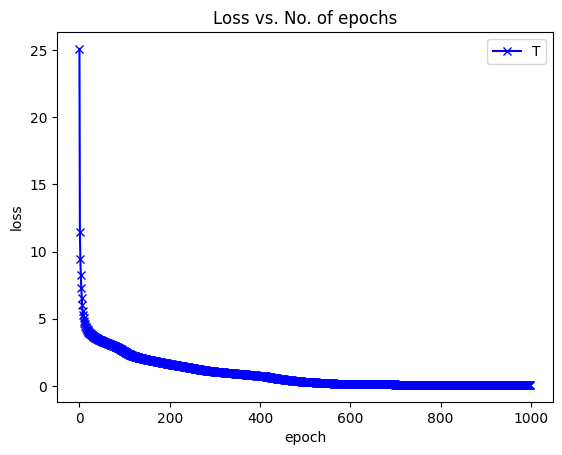

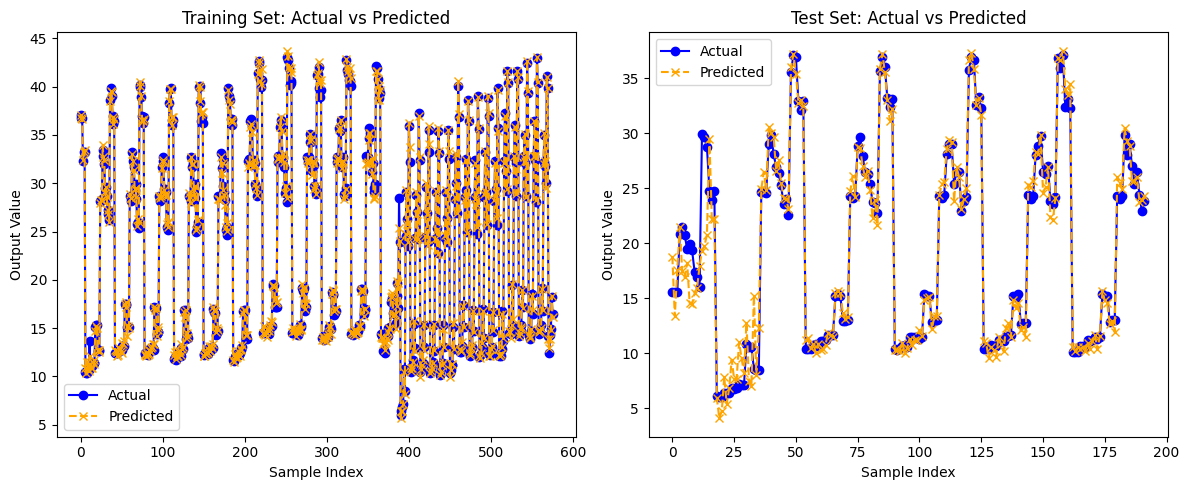

Model evaluation and visualization completed.


In [55]:
# Make predictions
y_train_pred = model.run_model(X_train.T).flatten()
y_test_pred = model.run_model(X_test.T).flatten()

# Calculate RMSE
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

train_rmse = rmse(y_train, y_train_pred)
test_rmse = rmse(y_test, y_test_pred)

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

# Visualize learning curve
def plot_losses(loss_history):
  plt.plot(loss_history, '-bx')
  plt.xlabel('epoch')
  plt.ylabel('loss')
  plt.legend('Training')
  plt.title('Loss vs. No. of epochs');

plot_losses(loss_history)
print("last loss: ", loss_history[-1])

def plot_predictions(y_train, y_train_pred, y_test, y_test_pred):
# Visualize predictions vs actual values
  plt.figure(figsize=(12, 5))

    # traing set
  plt.subplot(1, 2, 1)
  plt.plot(range(len(y_train)), y_train, label='Actual', color='blue', linestyle='-', marker='o')
  plt.plot(range(len(y_train_pred)), y_train_pred, label='Predicted', color='orange', linestyle='--', marker='x')
  plt.title('Training Set: Actual vs Predicted')
  plt.xlabel('Sample Index')
  plt.ylabel('Output Value')
  plt.legend()

    # testing set
  plt.subplot(1, 2, 2)
  plt.plot(range(len(y_test)), y_test, label='Actual', color='blue', linestyle='-', marker='o')
  plt.plot(range(len(y_test_pred)), y_test_pred, label='Predicted', color='orange', linestyle='--', marker='x')
  plt.title('Test Set: Actual vs Predicted')
  plt.xlabel('Sample Index')
  plt.ylabel('Output Value')
  plt.legend()

  plt.tight_layout()
  plt.show()
  
plot_predictions(y_train, y_train_pred, y_test, y_test_pred)

print("Model evaluation and visualization completed.")

# Feature Selection

Selected features:
Feature 0: 0.6223
Feature 1: 0.6581
Feature 2: 0.4557
Feature 3: 0.8618
Feature 4: 0.8894
Feature 5: 0.2698
Feature 10: 0.2054
Loss in epoch 0: 43.55692577856954
Loss in epoch 1: 9.401060431453914
Loss in epoch 2: 6.95564330235052
Loss in epoch 3: 5.482818345596414
Loss in epoch 4: 4.543708008056176
Loss in epoch 5: 3.939166544635818
Loss in epoch 6: 3.5714103589746315
Loss in epoch 7: 3.3165842017574216
Loss in epoch 8: 3.151413816339787
Loss in epoch 9: 2.998676377053247
Loss in epoch 10: 2.92074141581672
Loss in epoch 11: 2.858305638750686
Loss in epoch 12: 2.8023171547369716
Loss in epoch 13: 2.749381194613694
Loss in epoch 14: 2.70149185269697
Loss in epoch 15: 2.6751438048070733
Loss in epoch 16: 2.6143750564721286
Loss in epoch 17: 2.5630792141503305
Loss in epoch 18: 2.5162553487299033
Loss in epoch 19: 2.469990676624325
Loss in epoch 20: 2.4414148802303077
Loss in epoch 21: 2.3813308361604117
Loss in epoch 22: 2.3366827055669934
Loss in epoch 23: 2.299409329

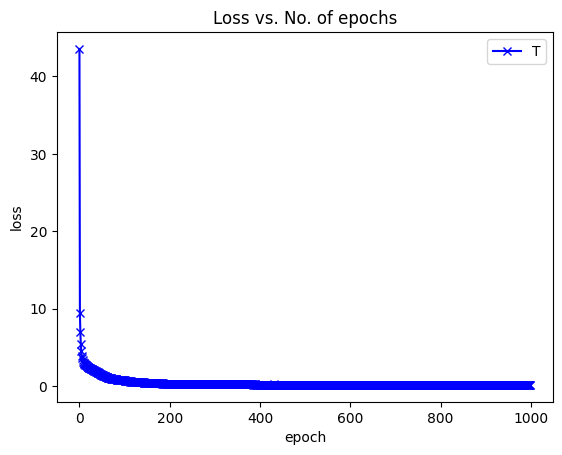

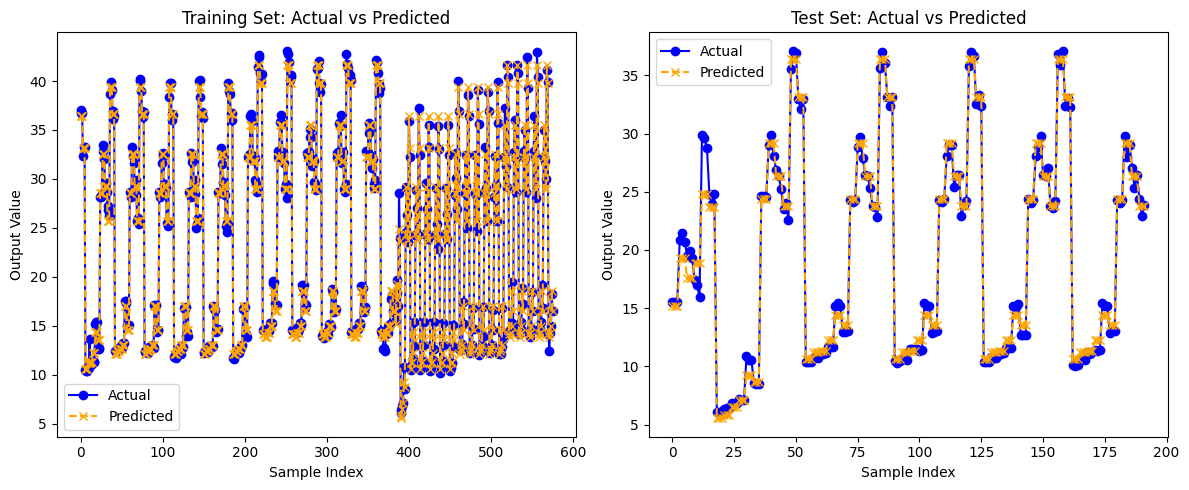

Feature selection and evaluation completed.


In [61]:
def feature_selection(X, Y, threshold=0.1):
    corr = np.abs(np.corrcoef(X.T, Y)[-1, :-1])
    selected_features = np.where(corr > threshold)[0]
    return selected_features, corr

# Perform feature selection
selected_features, feature_importance = feature_selection(X_encoded, Y)

print("Selected features:")
for feature, importance in zip(selected_features, feature_importance[selected_features]):
    print(f"Feature {feature}: {importance:.4f}")

# Train model with selected features
X_train_selected = X_train[:, selected_features]
X_test_selected = X_test[:, selected_features]

layers_dims_selected = [X_train_selected.shape[1]] + config['layers_dims'][1:]

model_selected = Net(layers_dims_selected)
losses_hidtory_selected = model_selected.train(X_train_selected.T, y_train.reshape(1, -1))

# Evaluate model with selected features
y_train_pred_selected = model_selected.run_model(X_train_selected.T).flatten()
y_test_pred_selected = model_selected.run_model(X_test_selected.T).flatten()

train_rmse_selected = rmse(y_train, y_train_pred_selected)
test_rmse_selected = rmse(y_test, y_test_pred_selected)

print(f"Training RMSE (selected features): {train_rmse_selected:.4f}")
print(f"Test RMSE (selected features): {test_rmse_selected:.4f}")

plot_losses(losses_hidtory_selected)
plot_predictions(y_train, y_train_pred_selected, y_test, y_test_pred_selected)

print("Feature selection and evaluation completed.")